# ML that can See: Supervised Learning with Images 

Let's load in any libraries we will use in this notebook. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

#import torch which has many of the functions to build deep learning models and to train them
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#import torchvision, which was lots of functions for loading and working with image data
import torchvision
import torchvision.transforms as transforms

#this is a nice progress bar representation that will be good to measure progress during training
import tqdm
import copy
import random

# fix seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #this line checks if we have a GPU available
print(f"Using device: {device}")

Using device: cpu


# Data

Train dataset size: 600
Internal test dataset size: 300
External test dataset size: 300


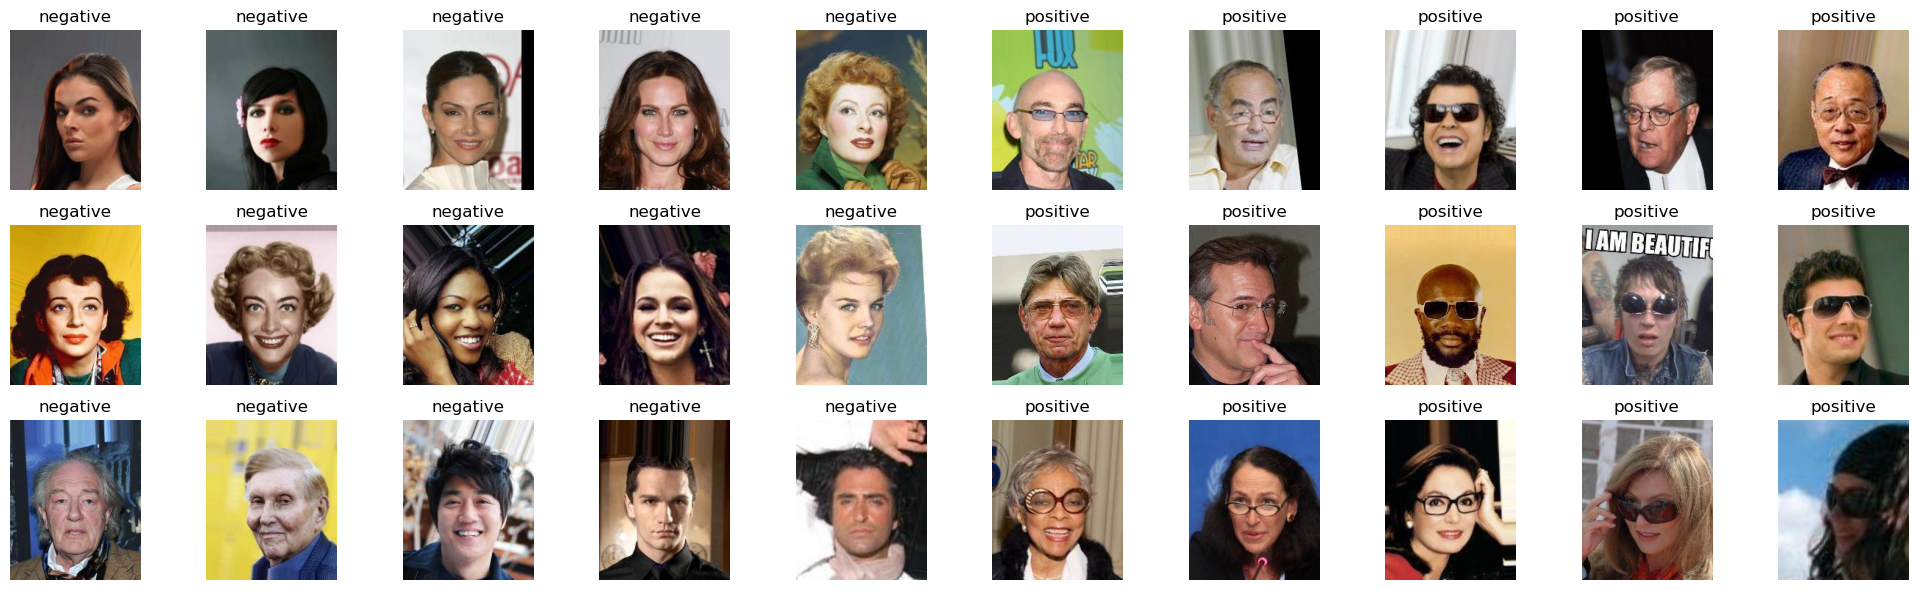

In [3]:
# Load the full training dataset first (without transforms for now)
train_dataset = torchvision.datasets.ImageFolder('Case2Dataset/train')
internal_dataset = torchvision.datasets.ImageFolder('Case2Dataset/test_internal')
external_dataset = torchvision.datasets.ImageFolder('Case2Dataset/test_external')


print(f'Train dataset size: {len(train_dataset)}')
print(f'Internal test dataset size: {len(internal_dataset)}')
print(f'External test dataset size: {len(external_dataset)}')
    
# Get class names and number of classes
class_names = train_dataset.classes
num_classes = len(class_names)

datasets = [train_dataset, internal_dataset, external_dataset]
dataset_names = ['Train', 'Internal Test', 'External Test']

fig, axes = plt.subplots(len(datasets), 5*num_classes, figsize=(20, 6))

for row_idx, (dataset, name) in enumerate(zip(datasets, dataset_names)):
    # Get indices for each class
    class_0_indices = [i for i, (_, label) in enumerate(dataset.samples) if label == 0]
    class_1_indices = [i for i, (_, label) in enumerate(dataset.samples) if label == 1]
    
    # Sample 5 images from each class
    selected_indices = np.random.choice(class_0_indices, 5, replace=False).tolist() + np.random.choice(class_1_indices, 5, replace=False).tolist()
    
    for col_idx, img_idx in enumerate(selected_indices):
        img, label = dataset[img_idx]
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].set_title(f'{class_names[label]}')
        axes[row_idx, col_idx].axis('off')
    
    axes[row_idx, 0].set_ylabel(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

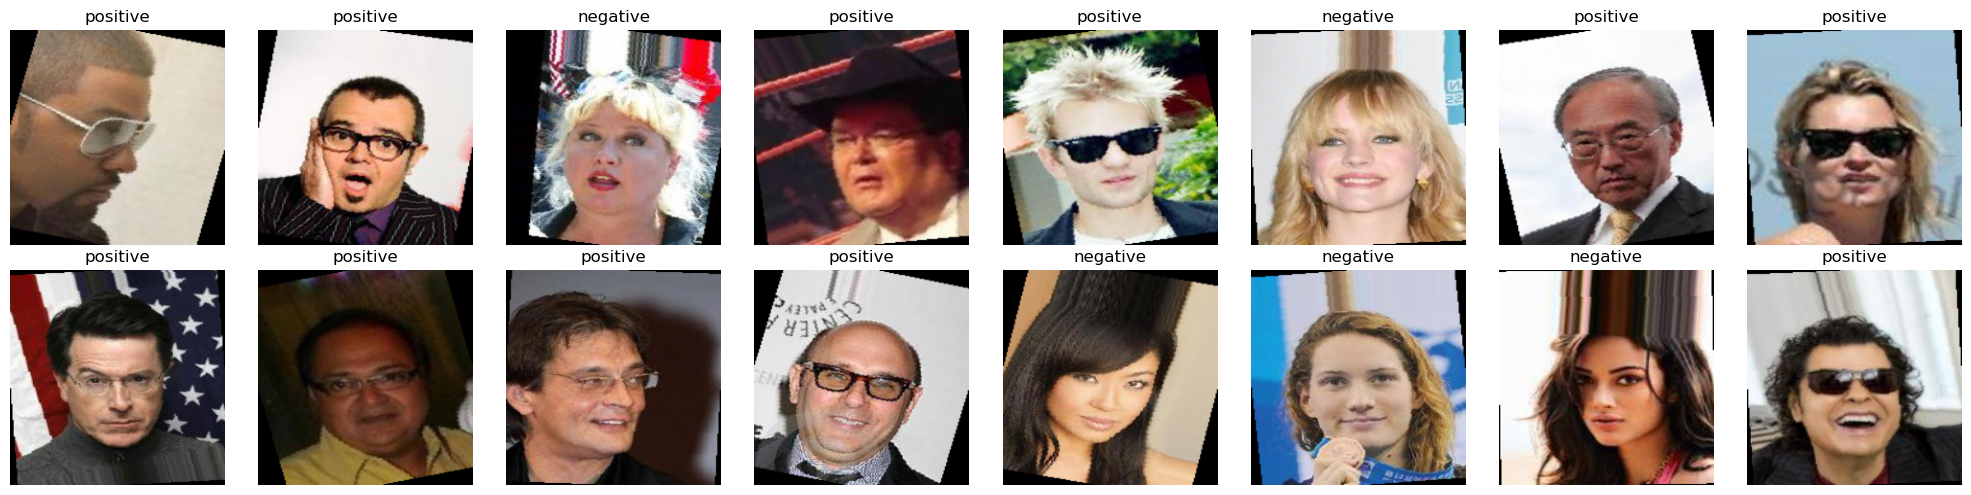

In [4]:

# Imnagenet preprocessing
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

# preprocessing transform
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((224, 224)), 
    transforms.Normalize(imagenet_means, imagenet_stds)])


# Data augmentation transforms for training set
train_transform = transforms.Compose(
    [transforms.RandomHorizontalFlip(),
     transforms.RandomRotation(15),
    ])

# Apply transforms to the datasets
train_dataset.transform = transforms.Compose([train_transform,transform])
internal_dataset.transform = transform
external_dataset.transform = transform

# create dataloaders for train, val, test datasets
batch_size = 16
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers = 1)
internalloader = torch.utils.data.DataLoader(internal_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)
externalloader = torch.utils.data.DataLoader(external_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)

# Visualize a batch of augmented training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Plot the batch
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
axes = axes.ravel()
for idx in range(min(16, len(images))):
    # Denormalize the image for visualization
    img = images[idx].numpy().transpose((1, 2, 0))
    # just remap for visualization
    img = img * np.array(imagenet_stds) + np.array(imagenet_means)
    img = np.clip(img, 0, 1)
    
    axes[idx].imshow(img)
    axes[idx].set_title(class_names[labels[idx]])
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# 2. The Model

In [5]:
def setup_model(model, num_classes, freeze_backbone = False):
    
    #### Adapt the architecture for the new number of classes.
    in_features = model.fc.in_features
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    #### If necessary, freeze any weights.
    if freeze_backbone: 
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the parameters of the last fully connected layer
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 2, False)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# 3. Training the Model with Transfer Learning

In [6]:
def train_epoch(model, dataloader, criterion, optimizer, epoch, device):

    # Put the model in "train" mode
    model.train() 

    # For all batches in the training dataset
    train_loss, correct, total = [], 0.0, 0.0
    for _, data in  tqdm.tqdm(enumerate(dataloader, 0), total = len(dataloader), desc = f'Epoch {epoch+1} - training phase'):
        # get the inputs and labels from the dataloader and move to device (GPU or CPU)
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero-out the gradients for this batch
        optimizer.zero_grad()

        # forward pass
        outputs = model(inputs)
        
        # calculate the loss, gradients with backpropagation, and update the weights
        loss = criterion(outputs, labels)        
        loss.backward()        
        optimizer.step()

        # accumulate loss and accuracy stats
        train_loss += [loss.cpu().item()]
        predicted = torch.argmax(outputs, axis = 1)        
        correct += torch.sum(predicted == labels).cpu().item()
        total += len(labels)

    # average stats for the epoch
    mean_train_loss = np.mean(train_loss)
    train_accuracy = correct/total
    print(f"Training {epoch+1}: loss={mean_train_loss:.3f} acc={train_accuracy:.3f}")

    return mean_train_loss, train_accuracy


In [7]:
def eval_epoch(model, dataloader, criterion, epoch, device):

    # Put the model in "eval" mode
    model.eval()
    
    #Validation loop: For all batches in the validation dataset
    with torch.no_grad(): # not build the computation graph for backpropagation, and thus, no gradients will be computed or stored for the tensors involved in those operations.
        val_loss, val_correct, val_total = 0.0, 0.0, 0.0
        for i, data in  tqdm.tqdm(enumerate(dataloader, 0), total = len(dataloader), desc = f'Epoch {epoch+1} - validation phase'):
            # get the inputs and labels from the dataloader and move to device (GPU or CPU)
            inputs, labels = data            
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # forward pass
            outputs = model(inputs)
            predicted = torch.argmax(outputs, axis = 1)
            
            # calculate the loss and accuracy at the validation split
            loss = criterion(outputs, labels)
            val_loss += loss.cpu().item() * inputs.size(0)            
            val_correct += torch.sum(predicted == labels).cpu().item()
            val_total += inputs.size(0)
    
    
    mean_val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total
    print(f"Validation {epoch+1}: loss={mean_val_loss:.3f} acc={val_accuracy:.3f}")
    return mean_val_loss, val_accuracy

Now let’s put everything together and train our model. Remember to save the best model, defined as the one that achieves the highest accuracy on the validation set at any epoch.

Epoch 1 - training phase: 100%|██████████| 38/38 [00:31<00:00,  1.21it/s]

Training 1: loss=0.336 acc=0.848



Epoch 1 - validation phase: 100%|██████████| 19/19 [00:10<00:00,  1.73it/s]

Validation 1: loss=0.097 acc=0.963
Best model found at epoch 0 with accuracy of 0.963



Epoch 2 - training phase: 100%|██████████| 38/38 [00:31<00:00,  1.21it/s]

...

Validation 9: loss=0.023 acc=0.987



Epoch 10 - training phase: 100%|██████████| 38/38 [00:31<00:00,  1.22it/s]

Training 10: loss=0.017 acc=0.997



Epoch 10 - validation phase: 100%|██████████| 19/19 [00:11<00:00,  1.65it/s]

Validation 10: loss=0.035 acc=0.987


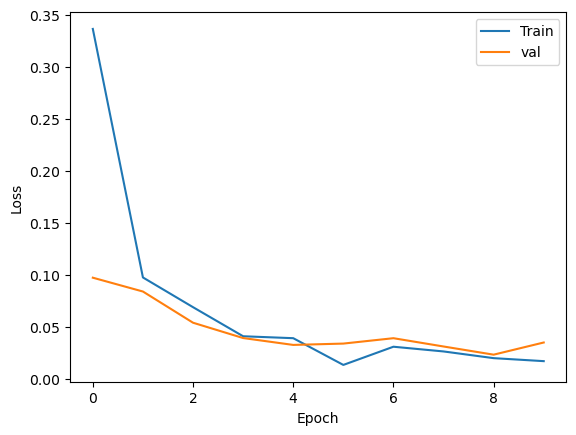

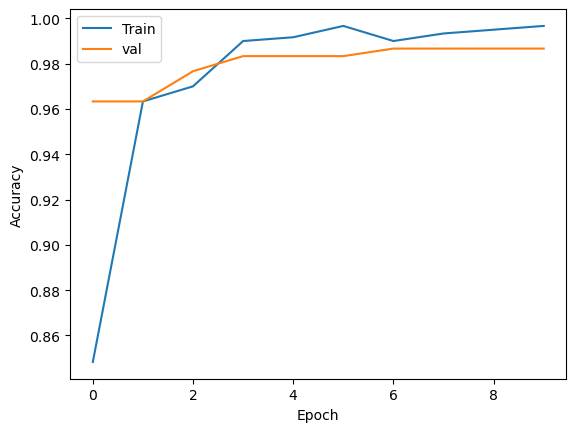

In [8]:
# any hyperparameters
lr = 0.001
total_epochs = 10

#Initialise the model.
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 2, False)
resnet_frozen = resnet_frozen.to(device)
# Define a loss function
criterion = nn.CrossEntropyLoss()

# Initialise the SGD optimizer.
optimizer = optim.SGD(resnet_frozen.parameters(), lr=lr, momentum=0.9)

#Step 4: For n epochs (e.g. loss converged/stops changing)
total_train_loss, total_val_loss = [], []
total_train_acc, total_val_acc = [], []
best_acc = -np.inf
for epoch in range(total_epochs):    

    # train for one epoch
    mean_train_loss, train_accuracy = train_epoch(resnet_frozen, trainloader, criterion, optimizer, epoch, device)
    total_train_loss.append(mean_train_loss); total_train_acc.append(train_accuracy);

    # evaluate on validation set
    mean_val_loss, val_accuracy = eval_epoch(resnet_frozen, internalloader, criterion, epoch, device)
    total_val_loss.append(mean_val_loss); total_val_acc.append(val_accuracy);

    # save the best model based on validation accuracy
    if val_accuracy > best_acc:
        torch.save(resnet_frozen.state_dict(), "resnet_frozen_best.pth")
        best_acc = val_accuracy
        print(f"Best model found at epoch {epoch} with accuracy of {best_acc:.3f}")


# Plot training and validation loss and accuracy curves
plt.plot(total_train_loss, label = 'Train')
plt.plot(total_val_loss, label = 'val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(total_train_acc, label = 'Train')
plt.plot(total_val_acc, label = 'val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# 4. Evaluation

In [9]:
# Load the best model
# resnet_frozen.load_state_dict(torch.load("resnet_frozen_best.pth"))
resnet_frozen.eval()

# Collect predictions and ground truth labels
all_predictions = {'internal': [], 'external': []}
all_labels = {'internal': [], 'external': []}

# compute predictions
with torch.no_grad():
    for split, dataloader in zip(['internal', 'external'], [internalloader, externalloader]):
        for data in tqdm.tqdm(dataloader, desc=f'Evaluating on {split} set'):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = resnet_frozen(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_predictions[split].append(probs.cpu().numpy())
            all_labels[split].append(labels.cpu().numpy())
print("Evaluation complete.")

for split in ['internal', 'external']:
    all_predictions[split] = np.concatenate(all_predictions[split], axis=0)
    all_labels[split] = np.concatenate(all_labels[split], axis=0)
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 19/19 [00:10<00:00,  1.77it/s]

Evaluation complete.
internal set - Accuracy: 0.987
external set - Accuracy: 0.780


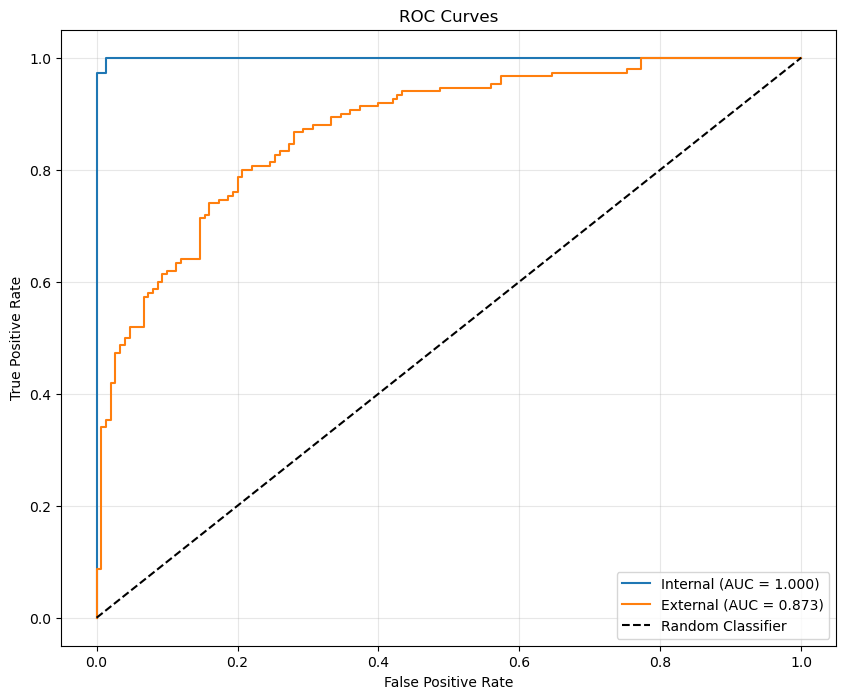

In [10]:
from sklearn.metrics import roc_curve, auc

# Plot ROC curves for both splits
plt.figure(figsize=(10, 8))

for split in ['internal', 'external']:
    # Get true labels and predicted probabilities for class 1
    true_labels = all_labels[split]
    pred_probs = all_predictions[split][:, 1]  # probability of class 1
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(true_labels, pred_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{split.capitalize()} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


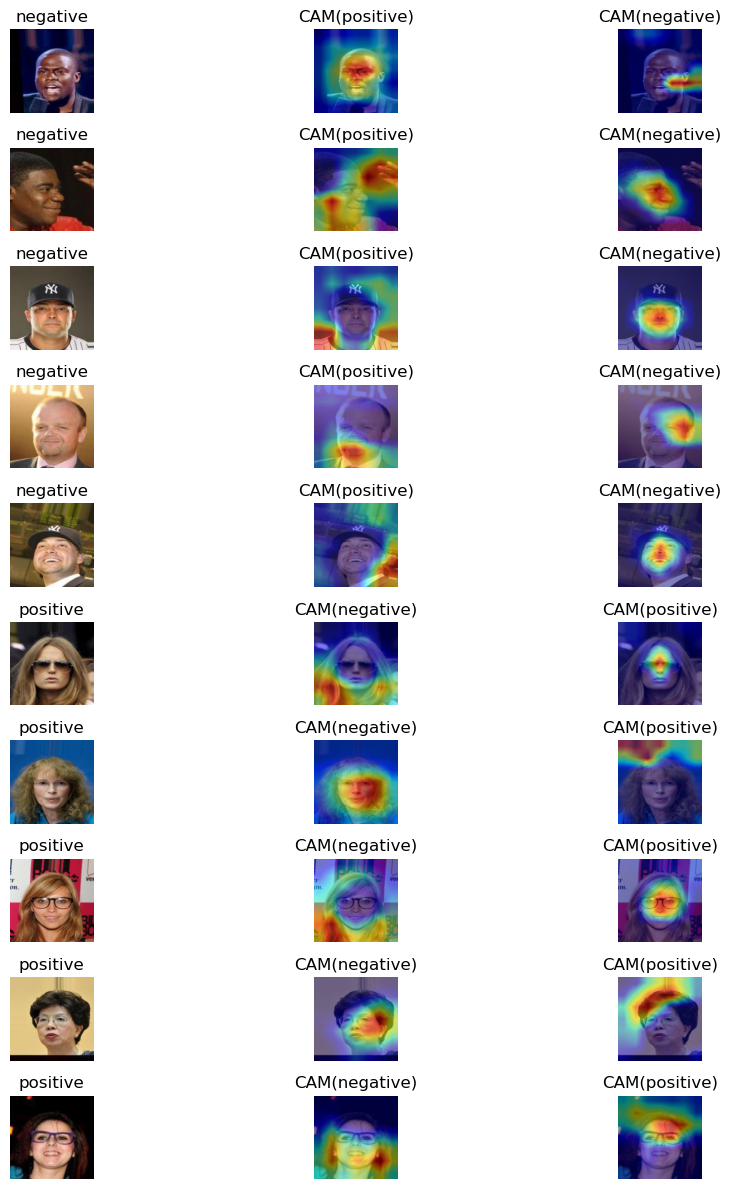

In [14]:
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook



# Get indices for each category
ext_preds = all_predictions['external'].argmax(axis=1)
ext_labels = all_labels['external']

tp_indices = np.where((ext_preds == 1) & (ext_labels == 1))[0]
tn_indices = np.where((ext_preds == 0) & (ext_labels == 0))[0]
fp_indices = np.where((ext_preds == 1) & (ext_labels == 0))[0]
fn_indices = np.where((ext_preds == 0) & (ext_labels == 1))[0]

selected_indices = []
selected_indices += np.random.choice(fp_indices, size=5, replace=False).tolist()  # False Positives
selected_indices += np.random.choice(fn_indices, size=5, replace=False).tolist()  # False Negatives

topk = 2
fig, axs = plt.subplots(len(selected_indices), topk+1, figsize=(5*topk+1,12))
resnet_frozen.layer4[1].register_forward_hook(get_activation('resnet.layer4.1.bn2'))
resnet_frozen.eval()

with torch.no_grad():
    for i, sel_idx in enumerate(selected_indices): 
        x, y = external_dataset[sel_idx]
        x = x.to(device)

        # plot original image
        x_display = x.detach().cpu().numpy().transpose(1, 2, 0) * imagenet_stds + imagenet_means
        x_display = np.clip(x_display, 0, 1)  # Clip to valid range [0, 1]
        axs[i, 0].imshow(x_display)       
        axs[i, 0].set_title(f'{external_dataset.classes[y]}'); axs[i, 0].axis('off');
        
        output = resnet_frozen(x.unsqueeze(0))
        topk_preds = torch.topk(output, k=topk, dim=1).indices  # top-5 predictions
        # topk_preds = np.ones_like(topk_preds)
        # conv_feature_map = activation['resnet.layer4.1.conv2'][0].detach()
        conv_feature_map = activation['resnet.layer4.1.bn2'][0].detach()
        
        # compute class activation maps for top-5 predictions
        for j, pred in enumerate(topk_preds[0]):
            fc_weights = resnet_frozen.state_dict()['fc.weight'][pred].detach()                
            cam = torch.sum(fc_weights[:,None,None] * conv_feature_map, axis=0)
            cam = cam.clip(min=0); cam = cam / torch.max(cam);
            cam = torch.nn.functional.interpolate(cam.unsqueeze(0).unsqueeze(0), size=(x.shape[1], x.shape[2])   , mode='bilinear', align_corners=False).squeeze().cpu().numpy()
            
            # plot CAM
            axs[i, j+1].imshow(x_display)
            axs[i, j+1].imshow(cam, alpha=0.5, cmap='jet')
            axs[i, j+1].set_title(f'CAM({external_dataset.classes[pred]})')
            axs[i, j+1].axis('off')
        
plt.tight_layout()
plt.show()
   